<a href="https://colab.research.google.com/github/phamanhnhatminh1809/ThucHanhDeepLearning/blob/main/THDL_Tuan02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regression phương pháp Gradient descent**

Khởi tạo dữ liệu

In [ ]:
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing(as_frame=True)
X_df = housing_data.data
y_df = housing_data.target

Tải bộ dữ liệu

In [ ]:
df = housing_data.data
df['MedHouseVal'] = housing_data.target

df.to_csv('california_housing.csv', index=False)

Thông số mô hình

In [ ]:
import numpy as np
import pandas as pd
print("==================================================")
print("   THÔNG TIN TỔNG QUAN VỀ BỘ DỮ LIỆU CALIFORNIA   ")
print("==================================================\n")

# A. KÍCH THƯỚC DỮ LIỆU
num_rows, num_cols = X_df.shape
print(f"1. Kích thước dữ liệu đầu vào (Features):")
print(f"   - Số lượng dòng (Mẫu dữ liệu): {num_rows:,} dòng")
print(f"   - Số lượng cột (Thuộc tính):   {num_cols} cột")
print(f"   - Kích thước nhãn cần dự đoán (Target): {y_df.shape[0]:,} dòng (1 cột giá nhà)\n")

# B. TÊN CÁC CỘT VÀ Ý NGHĨA
print("2. Danh sách các cột thuộc tính (X):")
print(list(X_df.columns))
print("   *Lưu ý ý nghĩa một số cột quan trọng:*")
print("   - MedInc: Thuộc tính quan trọng nhất (Thu nhập trung bình của khu vực - tính bằng chục nghìn USD).")
print("   - HouseAge: Tuổi thọ trung bình của nhà trong khu vực.")
print("   - AveRooms / AveBedrms: Số phòng ngủ / phòng khách trung bình.")
print("   - Population / AveOccup: Tổng dân số / Số người ở trung bình một hộ gia đình.")
print("   - Latitude / Longitude: Vĩ độ và Kinh độ của khu vực.\n")

   THÔNG TIN TỔNG QUAN VỀ BỘ DỮ LIỆU CALIFORNIA   

1. Kích thước dữ liệu đầu vào (Features):
   - Số lượng dòng (Mẫu dữ liệu): 20,640 dòng
   - Số lượng cột (Thuộc tính):   8 cột
   - Kích thước nhãn cần dự đoán (Target): 20,640 dòng (1 cột giá nhà)

2. Danh sách các cột thuộc tính (X):
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   *Lưu ý ý nghĩa một số cột quan trọng:*
   - MedInc: Thuộc tính quan trọng nhất (Thu nhập trung bình của khu vực - tính bằng chục nghìn USD).
   - HouseAge: Tuổi thọ trung bình của nhà trong khu vực.
   - AveRooms / AveBedrms: Số phòng ngủ / phòng khách trung bình.
   - Population / AveOccup: Tổng dân số / Số người ở trung bình một hộ gia đình.
   - Latitude / Longitude: Vĩ độ và Kinh độ của khu vực.

3. Kiểm tra dữ liệu khuyết thiếu (NaN/Null):
   - Tổng số ô bị khuyết dữ liệu: 0 (Tuyệt vời! Bộ dữ liệu hoàn toàn sạch sẽ)

4. Thống kê khoảng giá trị (Min - Max) của một số thuộc tính nổi bật:
      MedIn

Tiền xử lý dữ liệu

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def tien_xu_ly_du_lieu(housing_data):
    housing_data_dataframe = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

    # Scale kieu min max
    min_max_scaler = MinMaxScaler(feature_range=(0, 1))
    minmax_scale_coulumn = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]

    scaled_data = min_max_scaler.fit_transform(housing_data_dataframe[minmax_scale_coulumn])

    processed_data = housing_data_dataframe.copy()
    processed_data[minmax_scale_coulumn] = scaled_data

    return processed_data



              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   

            Latitude  Longitude  
MedInc     -0.079809  -0.015176  
HouseAge    0.011173  -0.108197  
AveRooms    0.106389  -0.027540  
AveBedrms   0.069721   0.013344  
Population -0.108785   0.099773  
AveOccup    0.002366   0.002476  
Latitude    1.000000  -0.924664  
Longitude  -0.924664   1.000000  


Mô hình Regression - Gradient Descent sử dụng TensorFlow

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_california_housing

def xay_dung_mo_hinh_regression_tensorflow(input_shape):
    mo_hinh_regression = Sequential(name="RegressionModel")
    mo_hinh_regression.add(Input(shape = (input_shape,)))
    mo_hinh_regression.add(Dense(units=1, activation=None, name="Lop_Linear"))
    thuat_toan_gradient_descent = SGD(learning_rate=0.01)

    mo_hinh_regression.compile(
        optimizer=thuat_toan_gradient_descent,
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return mo_hinh_regression

if __name__ == "__main__":
    raw_data = fetch_california_housing()

    # Tiền xử lý dữ liệu (X) và lấy nhãn (y)
    X_processed = tien_xu_ly_du_lieu(raw_data)
    y = raw_data.target

    # Lấy số lượng cột đầu vào (Số thuộc tính = 8)
    so_luong_cot = X_processed.shape[1]

    model = xay_dung_mo_hinh_regression_tensorflow(input_shape=so_luong_cot)

    print("\n=== CẤU TRÚC MÔ HÌNH ===")
    model.summary()

    print("\n=== HUẤN LUYỆN MÔ HÌNH GRADIENT DESCENT ===")
    model.fit(X_processed, y, epochs=10, batch_size=32)



=== CẤU TRÚC MÔ HÌNH ===


Model: "RegressionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Lop_Linear (Dense)              │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)


=== HUẤN LUYỆN MÔ HÌNH GRADIENT DESCENT ===
Epoch 1/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3535 - mean_absolute_error: 0.9032
Epoch 2/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0070 - mean_absolute_error: 0.7930
Epoch 3/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8651 - mean_absolute_error: 0.7306
Epoch 4/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7729 - mean_absolute_error: 0.6844
Epoch 5/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7121 - mean_absolute_error: 0.6507
Epoch 6/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6716 - mean_absolute_error: 0.6268
Epoch 7/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6444 - mean_absolute_error: 0.6092
Epoch 8/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6259 - mean_absolute_error: 0.5973
Epoch 9/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6130 - mean_absolute_error: 0.5879
Epoch 10/10
645/645 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6034 - mean_absolut

Mô hình Regression - Gradient Descent chỉ sử dụng numpy

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler

# Giả định hàm tiền xử lý dữ liệu của bạn đã chạy đúng ổn định
def tien_xu_ly_du_lieu(housing_data):
    housing_data_dataframe = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
    min_max_scaler = MinMaxScaler(feature_range=(0, 1))
    minmax_scale_coulumn = ["MedInc", "HouseAge","AveRooms","AveBedrms","Population","AveOccup","Latitude","Longitude"]
    scaled_data = min_max_scaler.fit_transform(housing_data_dataframe[minmax_scale_coulumn])
    processed_data = housing_data_dataframe.copy()
    processed_data[minmax_scale_coulumn] = scaled_data
    return processed_data

class ModelLinearRegressionNumpy:
    def __init__(self, input_shape, learning_rate=0.01):
        """
        Đầu vào:
        input_shape: Một số nguyên đơn thuần (Số lượng cột thuộc tính $M$).learning_rate: Một số thực đơn thuần (Hệ số bước nhảy).

        Giá trị khởi tạo:
        Giả sử x ma trận đầu vào có N dòng và M cột
        self.W (Trọng số): Shape (M, 1). Số dòng tương ứng với số thuộc tính của ma trận đầu vào
        self.b (Sai số tự do): Số thực
        """
        self.lr = learning_rate
        self.W = np.random.randn(input_shape, 1) * 0.01
        self.b = 0.0

    def predict(self, X):
        """
        Đầu vào:
        X: Ma trận dữ liệu đặc trưng, có hình dạng (N, M).

        Phép toán bên trong:
        X(N, M) tích vô hướng self.W (M, 1) cho ra kết quả có shape (N, 1)
        Sau đó cộng với self.b (Số thực)

        Đầu ra:
        Mảng kết quả dự đoán y_du_doan, có hình dạng (N, 1).
        => Mỗi dòng dữ liệu của X trả ra đúng 1 kết quả dự đoán.
        """
        return np.dot(X, self.W) + self.b

    def tinh_loss_mse(self, y_thuc_te, y_du_doan):
        """
        Đầu vào:
        y_thuc_te: Ma trận nhãn thực tế, có hình dạng (N, 1).
        y_du_doan: Ma trận nhãn dự đoán, có hình dạng (N, 1).

        Phép toán bên trong:
        (y_thuc_te (N, 1) - y_du_doan (N, 1)^2 sau đó hàm np.mean() sẽ tính trung bình cộng của toàn bộ mảng này.

        Đầu ra:
        Trả về một Số thực đơn thuần duy nhất đại diện cho sai số trung bình của toàn bộ tập dữ liệu.
        """
        return np.mean((y_thuc_te - y_du_doan) ** 2)

    def huan_luyen_mo_hinh_gradient_descend(self, X, y, epochs=10):
        so_luong_dong_du_lieu = X.shape[0]

        for epoch in range(epochs):
            y_du_doan = self.predict(X)

            loss = self.tinh_loss_mse(y, y_du_doan)

            sai_so_tu_du_doan = y_du_doan - y

            # Đạo hàm riêng cho từng trọng số
            dW = (2 / so_luong_dong_du_lieu) * np.dot(X.T, sai_so_tu_du_doan)

            # Tổng các sai số lại
            db = (2 / so_luong_dong_du_lieu) * np.sum(sai_so_tu_du_doan)

            # Cập nhật tham số trọng số và sai số
            self.W -= self.lr * dW
            self.b -= self.lr * db

            if (epoch + 1) % 10 == 0 or epoch == 0:
                mae = np.mean(np.abs(y - y_du_doan))
                print(f"Epoch {epoch + 1:03d}/{epochs} - loss (MSE): {loss:.4f} - mean_absolute_error: {mae:.4f}")

if __name__ == "__main__":
    raw_data = fetch_california_housing()

    X_processed = tien_xu_ly_du_lieu(raw_data).values

    # Ma trận y (N dòng, 1 cột)
    y = raw_data.target.reshape(-1, 1)

    # Số lượng cột thuộc tính đầu vào (8 cột)
    so_luong_cot = X_processed.shape[1]

    print("=== BẮT ĐẦU HUẤN LUYỆN BẰNG PYTHON THUẦN (NUMPY) ===")
    model = ModelLinearRegressionNumpy(input_shape=so_luong_cot, learning_rate=0.05)

    model.huan_luyen_mo_hinh_gradient_descend(X_processed, y, epochs=100)

    print("\n=== THAM SỐ MÔ HÌNH TÌM ĐƯỢC ===")
    print("Trọng số W cho từng cột:\n", model.W)
    print("Hệ số tự do b (Bias):", model.b)

=== BẮT ĐẦU HUẤN LUYỆN BẰNG PYTHON THUẦN (NUMPY) ===
Epoch 001/100 - loss (MSE): 5.6252 - mean_absolute_error: 2.0718
Epoch 010/100 - loss (MSE): 1.4323 - mean_absolute_error: 0.8794
Epoch 020/100 - loss (MSE): 1.2607 - mean_absolute_error: 0.8788
Epoch 030/100 - loss (MSE): 1.2351 - mean_absolute_error: 0.8795
Epoch 040/100 - loss (MSE): 1.2140 - mean_absolute_error: 0.8735
Epoch 050/100 - loss (MSE): 1.1937 - mean_absolute_error: 0.8664
Epoch 060/100 - loss (MSE): 1.1741 - mean_absolute_error: 0.8593
Epoch 070/100 - loss (MSE): 1.1552 - mean_absolute_error: 0.8523
Epoch 080/100 - loss (MSE): 1.1370 - mean_absolute_error: 0.8455
Epoch 090/100 - loss (MSE): 1.1194 - mean_absolute_error: 0.8388
Epoch 100/100 - loss (MSE): 1.1024 - mean_absolute_error: 0.8323

=== THAM SỐ MÔ HÌNH TÌM ĐƯỢC ===
Trọng số W cho từng cột:
 [[1.21630301]
 [0.63537659]
 [0.06717502]
 [0.01629161]
 [0.05170767]
 [0.01102994]
 [0.11057358]
 [0.40914583]]
Hệ số tự do b (Bias): 1.2072445583003923


# **Mô hình ANN**

3. CÀI ĐẶT ARTIFICIAL NEURAL NETWORK CƠ BẢN
Đầu vào:
- Tập ảnh thời trang kích thước 28 x 28
Đầu ra:
- Một mảng chứa xác suất các label (mang giá trị 0 đến 9)

3.1. Nạp thư viện

In [ ]:
! pip install scikeras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense, Dropout
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler


3.2. Đọc tập dữ liệu FASHION MNIST

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion.load_data()

print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape:  (60000, 28, 28)
y_train shape:  (60000,)
x_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


3.3. Xử lý dữ liệu

In [ ]:
"""
Reshape từ ma trận 3 chiều sang ma trận 2 chiều:
60000 dòng dữ liệu, 28x28 xếp thành một vector
"""
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

minmax_scaler = MinMaxScaler()

x_train = minmax_scaler.fit_transform(x_train)
x_test = minmax_scaler.transform(x_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))


Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


3.4. Trực quan hóa dữ liệu

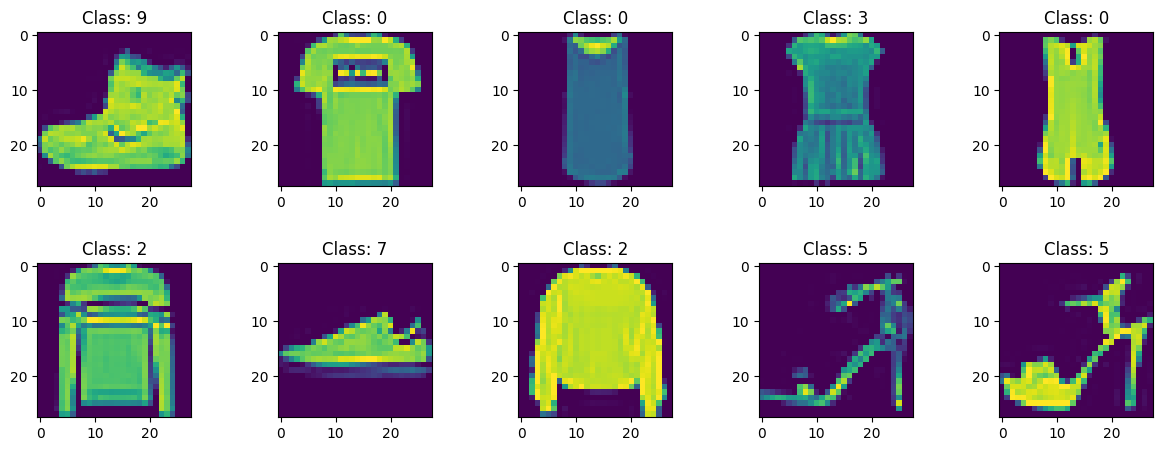

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(x_train[i].reshape(28, 28))
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

3.5. Xây dựng mô hình học ANN

In [ ]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=x_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

3.6. Huấn luyện ANN model

In [ ]:
model_fit = fashion_model.fit(x_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.8208 - loss: 0.5083 - val_accuracy: 0.8590 - val_loss: 0.3956
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8636 - loss: 0.3741 - val_accuracy: 0.8685 - val_loss: 0.3747
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8777 - loss: 0.3355 - val_accuracy: 0.8787 - val_loss: 0.3450
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8861 - loss: 0.3080 - val_accuracy: 0.8780 - val_loss: 0.3428
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8913 - loss: 0.2917 - val_accuracy: 0.8830 - val_loss: 0.3276
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8981 - loss: 0.2760 - val_accuracy: 0.8795 - val_loss: 0.3373
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9022 - loss: 0.2618 - val_accuracy: 0.8767 - val_loss: 0.3436
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9064 - loss: 0.2

3.7. Đánh giá ANN mode

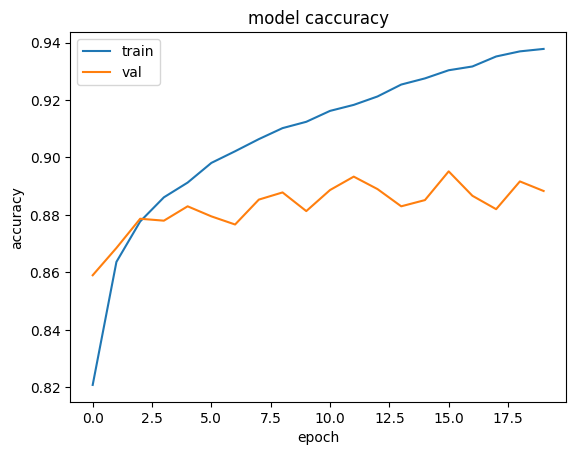

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model caccuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

3.8. Dự báo ảnh mới

In [ ]:
print(np.argmax(fashion_model.predict(x_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(x_test)[2]), y_test[2])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1 1


3.9. Đọc tập dữ liệu từ file

# **Bài tập ANN**

1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

In [2]:
! pip install scikeras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense, Dropout
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

Khởi tạo dữ liệu

In [12]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (50000, 32, 32, 3)
y_train shape:  (50000, 1)
x_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 1)


Trực quan hóa dữ liệu

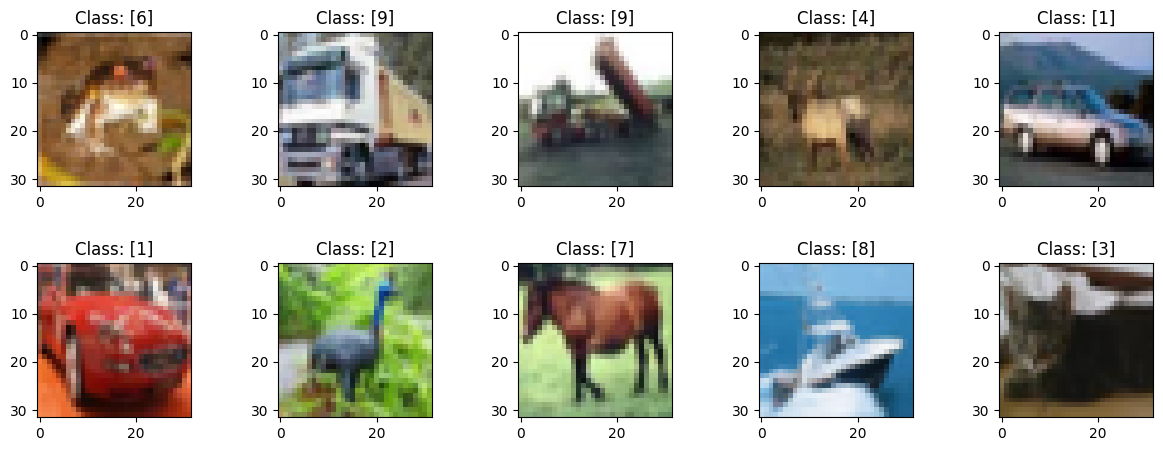

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(x_train[i])
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

Xử lý dữ liệu

In [14]:
"""
Reshape từ ma trận 3 chiều sang ma trận 2 chiều:
"""
x_train = x_train.reshape(50000, 3072)
x_test = x_test.reshape(10000, 3072)

minmax_scaler = MinMaxScaler()

x_train = minmax_scaler.fit_transform(x_train)
x_test = minmax_scaler.transform(x_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))


Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


Xây dựng mô hình

In [15]:
mo_hinh_ann_bt_1 = Sequential()
mo_hinh_ann_bt_1.add(Dense(input_dim=x_train.shape[1], units=512, kernel_initializer='he_uniform'))
mo_hinh_ann_bt_1.add(Dense(units=10, kernel_initializer='he_uniform', activation='softmax'))
mo_hinh_ann_bt_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

mo_hinh_ann_bt_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [ ]:
mo_hinh_ann_bt_1_fit = mo_hinh_ann_bt_1.fit(x_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.3012 - loss: 2.3062 - val_accuracy: 0.3294 - val_loss: 1.8736
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.3451 - loss: 1.8590 - val_accuracy: 0.3408 - val_loss: 1.8423
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.3467 - loss: 1.8565 - val_accuracy: 0.3066 - val_loss: 1.9740
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.3532 - loss: 1.8457 - val_accuracy: 0.3304 - val_loss: 1.9863
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.3599 - loss: 1.8335 - val_accuracy: 0.3562 - val_loss: 1.8782
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.3642 - loss: 1.8221 - val_accuracy: 0.3542 - val_loss: 1.8393
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.3671 - loss: 1.8143 - val_accuracy: 0.3562 - val_loss: 1.8480
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.3699 -

Đánh giá ANN mode

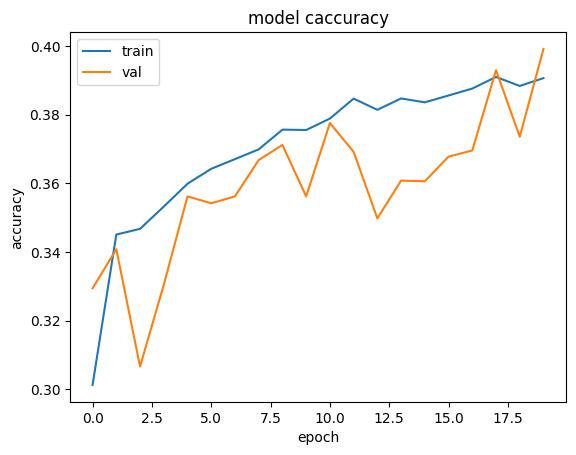

In [18]:
plt.plot(mo_hinh_ann_bt_1_fit.history['accuracy'])
plt.plot(mo_hinh_ann_bt_1_fit.history['val_accuracy'])
plt.title('model caccuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Dự báo kết quả

In [20]:
print(np.argmax(mo_hinh_ann_bt_1.predict(x_test)[0]), y_test[0])
print(np.argmax(mo_hinh_ann_bt_1.predict(x_test)[2]), y_test[2])

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
3 [3]
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
8 [8]


2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên cung cấp với các nhãn sau

Khởi tạo dữ liệu

In [27]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (60000, 28, 28)
y_train shape:  (60000,)
x_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


Trực quan hóa dữ liệu

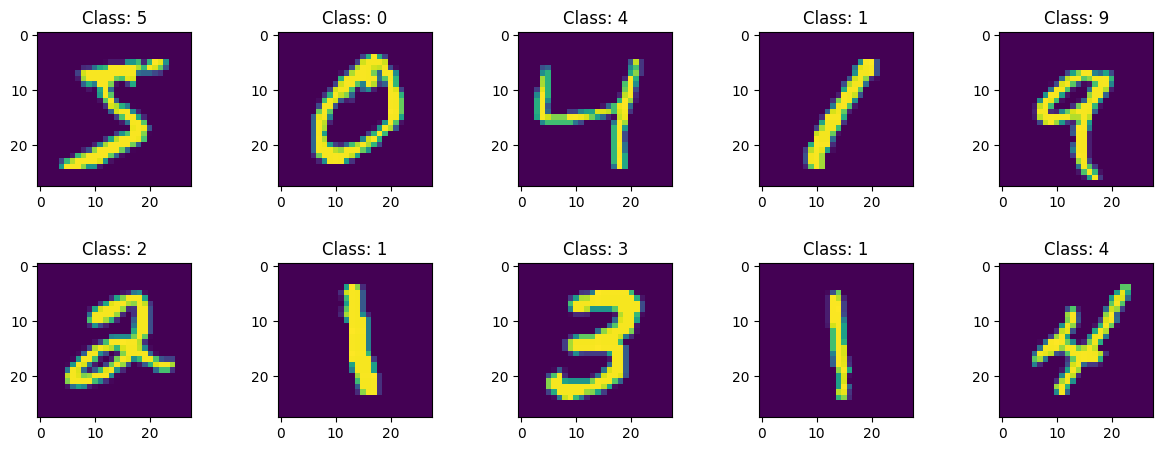

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(x_train[i])
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

Xử lý dữ liệu

In [29]:
"""
Reshape từ ma trận 3 chiều sang ma trận 2 chiều:
"""
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

minmax_scaler = MinMaxScaler()

x_train = minmax_scaler.fit_transform(x_train)
x_test = minmax_scaler.transform(x_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))


Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


Xây dựng mô hình

In [30]:
mo_hinh_ann_bt_2 = Sequential()
mo_hinh_ann_bt_2.add(Dense(input_dim=x_train.shape[1], units=512, kernel_initializer='he_uniform'))
mo_hinh_ann_bt_2.add(Dense(units=10, kernel_initializer='he_uniform', activation='softmax'))
mo_hinh_ann_bt_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

mo_hinh_ann_bt_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [31]:
mo_hinh_ann_bt_2_fit = mo_hinh_ann_bt_2.fit(x_train, y_train, validation_split=0.1, epochs=3, verbose=1)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8922 - loss: 0.3794 - val_accuracy: 0.9193 - val_loss: 0.2766
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9093 - loss: 0.3227 - val_accuracy: 0.9272 - val_loss: 0.2617
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9114 - loss: 0.3129 - val_accuracy: 0.9315 - val_loss: 0.2578


Đánh giá ANN mode

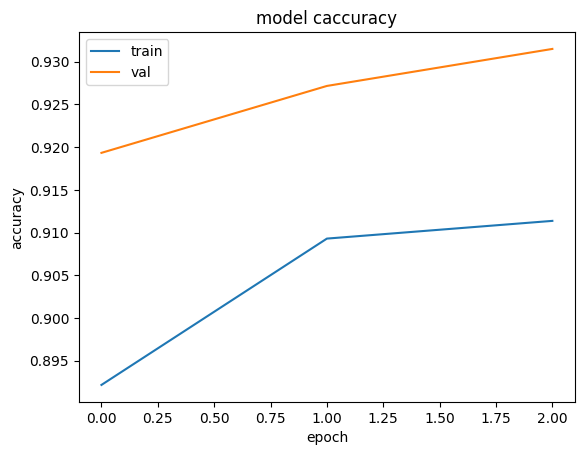

In [37]:
plt.plot(mo_hinh_ann_bt_2_fit.history['accuracy'])
plt.plot(mo_hinh_ann_bt_2_fit.history['val_accuracy'])
plt.title('model caccuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Dự đoán

In [36]:
print(np.argmax(mo_hinh_ann_bt_2.predict(x_test)[0]), y_test[0])
print(np.argmax(mo_hinh_ann_bt_2.predict(x_test)[2]), y_test[2])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7 7
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1 1
